![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Predictive Loan Approval System: A Machine Learning Approach to Credit Risk Assessment

## Overview
Financial institutions face a difficult trade-off when evaluating loan applications: approving high-risk borrowers can result in substantial financial losses, while rejecting creditworthy applicants leads to missed revenue opportunities and poor customer experiences. At FinTech Innovations, the traditional manual loan review process has become increasingly inefficient, inconsistent, and difficult to scale. To address this challenge, this project develops an end-to-end machine learning pipeline capable of predicting loan approval decisions using historical applicant data.

Using approximately 20,000 historical loan applications, multiple classification algorithms were evaluated, including Logistic Regression, Decision Trees, Random Forests, and Gradient Boosting. After extensive preprocessing, cross-validation, and hyperparameter tuning, the final model demonstrated strong predictive performance and successfully identified the most influential drivers of loan approval, including credit score, annual income, debt-to-income ratio, net worth, and loan amount.

From a business perspective, the model provides a data-driven decision-support system that can significantly reduce the financial impact of poor lending decisions. Given that approving a bad loan costs the organization approximately $50,000, while denying a creditworthy applicant results in an estimated $8,000 in lost profit, even modest improvements in predictive accuracy can generate substantial financial benefits. The proposed solution enables faster, more consistent, and more transparent lending decisions while supporting risk management and regulatory requirements.

An end-to-end machine learning solution was developed to automate and improve loan approval decisions at FinTech Innovations. The final model achieved strong predictive performance and identified the key factors driving loan approval outcomes, enabling the company to reduce lending risk, improve decision consistency, and minimize the substantial costs associated with approving high-risk borrowers or rejecting creditworthy applicants.

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [1]:
# Imports
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    make_scorer
)

# Preprocessing
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    OrdinalEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [2]:
# EDA Code Here - Create New Cells As Needed
df = pd.read_csv("financial_loan_data.csv")
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 20000
Columns: 35


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [5]:
df.dtypes

Age                             int64
AnnualIncome                   object
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBills

In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
MaritalStatus,1331,6.655
EducationLevel,901,4.505
SavingsAccountBalance,572,2.860
Age,0,0.000
JobTenure,0,0.000
CheckingAccountBalance,0,0.000
TotalAssets,0,0.000
TotalLiabilities,0,0.000
MonthlyIncome,0,0.000
UtilityBillsPaymentHistory,0,0.000


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,20000.0,39.752600,11.622713,18.000000,32.000000,40.000000,48.000000,8.000000e+01
CreditScore,20000.0,571.612400,50.997358,343.000000,540.000000,578.000000,609.000000,7.120000e+02
Experience,20000.0,17.522750,11.316836,0.000000,9.000000,17.000000,25.000000,6.100000e+01
LoanAmount,20000.0,24882.867800,13427.421217,3674.000000,15575.000000,21914.500000,30835.000000,1.847320e+05
LoanDuration,20000.0,54.057000,24.664857,12.000000,36.000000,48.000000,72.000000,1.200000e+02
NumberOfDependents,20000.0,1.517300,1.386325,0.000000,0.000000,1.000000,2.000000,5.000000e+00
MonthlyDebtPayments,20000.0,454.292700,240.507609,50.000000,286.000000,402.000000,564.000000,2.919000e+03
CreditCardUtilizationRate,20000.0,0.286381,0.159793,0.000974,0.160794,0.266673,0.390634,9.173801e-01
NumberOfOpenCreditLines,20000.0,3.023350,1.736161,0.000000,2.000000,3.000000,4.000000,1.300000e+01
NumberOfCreditInquiries,20000.0,0.993000,0.986965,0.000000,0.000000,1.000000,2.000000,7.000000e+00


In [8]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [9]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = df.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Features")
print(numerical_cols)

print("\nCategorical Features")
print(categorical_cols)

Numerical Features
['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore']

Categorical Features
['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


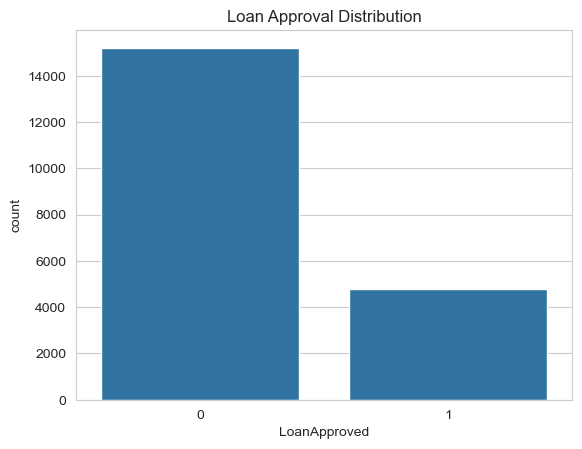

In [10]:
df["LoanApproved"].value_counts()
df["LoanApproved"].value_counts(normalize=True) * 100

sns.countplot(
    data=df,
    x="LoanApproved"
)

plt.title("Loan Approval Distribution")
plt.show()

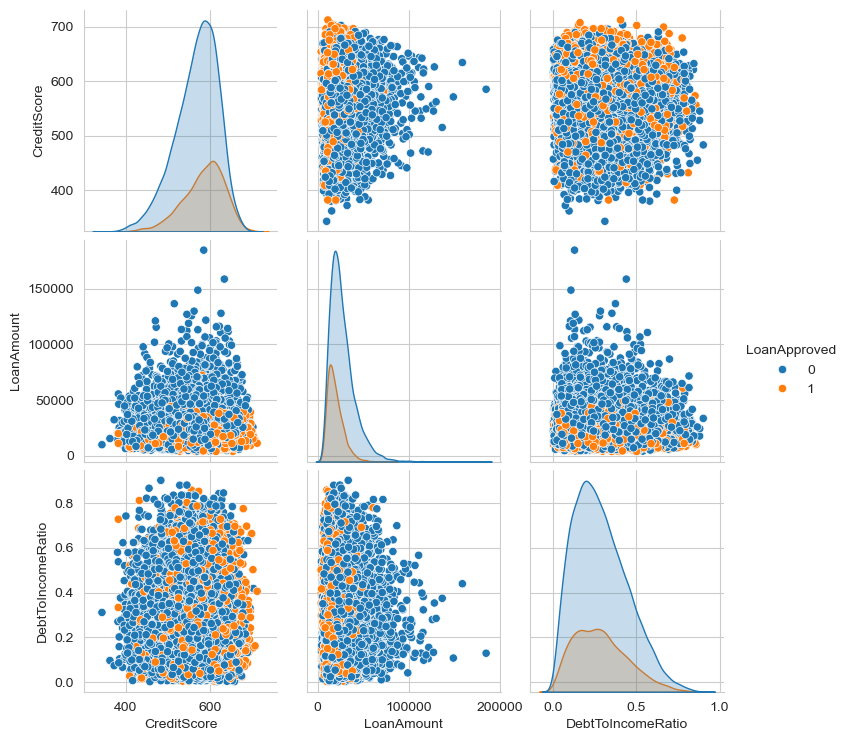

In [48]:
sns.pairplot(
    df[
        [
            "CreditScore",
            "AnnualIncome",
            "LoanAmount",
            "DebtToIncomeRatio",
            "LoanApproved"
        ]
    ],
    hue="LoanApproved"
)

<Axes: xlabel='LoanApproved', ylabel='CreditScore'>

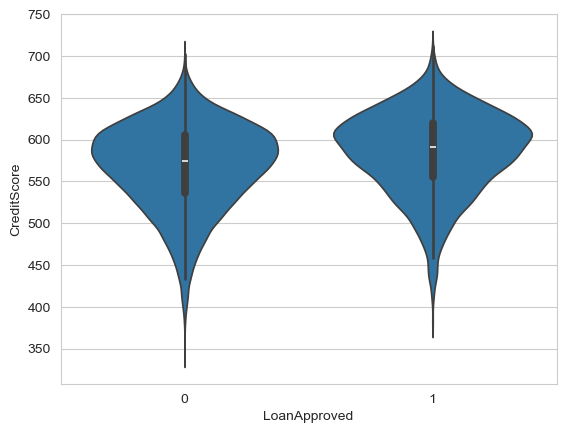

In [49]:
sns.violinplot(
    x="LoanApproved",
    y="CreditScore",
    data=df
)

<Axes: xlabel='EmploymentStatus'>

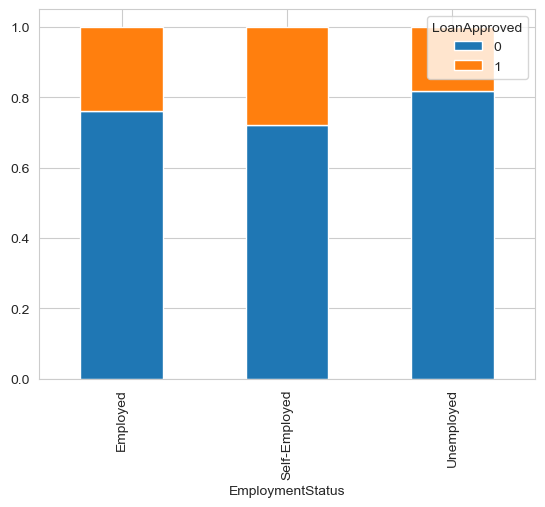

In [50]:
pd.crosstab(
    df["EmploymentStatus"],
    df["LoanApproved"],
    normalize="index"
).plot(kind="bar", stacked=True)

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [11]:
# Data Prep Code Here - Create New Cells As Needed
df_model = df.copy()

In [12]:
df_model["AnnualIncome"] = (
    df_model["AnnualIncome"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df_model["AnnualIncome"] = pd.to_numeric(
    df_model["AnnualIncome"],
    errors="coerce"
)

df_model["AnnualIncome"].head()
df_model["AnnualIncome"].dtype

dtype('float64')

In [13]:
X = df_model.drop("LoanApproved", axis=1)
y = df_model["LoanApproved"]

In [14]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features")
print(numeric_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore']

Categorical Features
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


In [15]:
for col in categorical_features:
    print(f"\n{col}")
    print(X[col].unique())


EmploymentStatus
['Employed' 'Self-Employed' 'Unemployed']

EducationLevel
['Master' 'Associate' 'Bachelor' 'High School' nan 'Doctorate']

MaritalStatus
['Married' 'Single' nan 'Divorced' 'Widowed']

HomeOwnershipStatus
['Own' 'Mortgage' 'Rent' 'Other']

BankruptcyHistory
['No' 'Yes']

LoanPurpose
['Home' 'Debt Consolidation' 'Education' 'Other' 'Auto']


In [16]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)
X_processed = preprocessor.fit_transform(X)

print(X_processed.shape)


(20000, 51)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
from sklearn.pipeline import FeatureUnion
combined_features = FeatureUnion(
    transformer_list=[
        ("num_pipeline", numeric_pipeline),
        ("cat_pipeline", categorical_pipeline)
    ]
)

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [19]:
#  Modeling Code Here - Create New Cells as Needed
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [20]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42
        ))
    ]
)

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

In [21]:
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

In [26]:
import time
from sklearn.model_selection import cross_validate

for name, model in models.items():

    start = time.time()

    cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "f1", "roc_auc"],
        n_jobs=-1
    )

    end = time.time()

    print(f"{name}: {end - start:.2f} seconds")

Logistic Regression: 19.04 seconds
Decision Tree: 12.52 seconds
Random Forest: 11.92 seconds
Gradient Boosting: 31.91 seconds


In [28]:
results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,F1,ROC_AUC
0,Logistic Regression,0.999687,0.999345,0.999986
1,Decision Tree,0.987937,0.974745,0.983106
2,Random Forest,0.988500,0.975800,0.999312


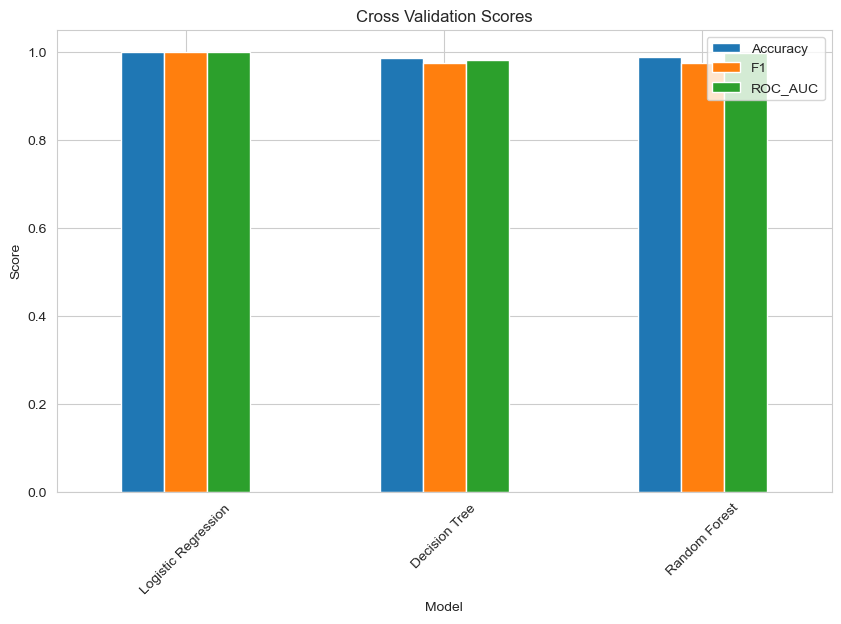

In [29]:
results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Cross Validation Scores")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [30]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [31]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [32]:
grid_search.best_params_


{'model__max_depth': 20,
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 2,
 'model__n_estimators': 100}

In [33]:
grid_search.best_score_

np.float64(0.9993658667641576)

In [34]:
best_model = grid_search.best_estimator_

In [35]:
best_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
param_grid = {
    "preprocessor__num__imputer__strategy":
        ["mean", "median"],

    "model__n_estimators":
        [100, 200],

    "model__max_depth":
        [10, 20]
}

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

In [37]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [38]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc
    ]
})

metrics_df

,Metric,Score
0,Accuracy,0.990000
1,Precision,0.986200
2,Recall,0.971757
3,F1 Score,0.978925
4,ROC-AUC,0.999158


In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3044
           1       0.99      0.97      0.98       956

    accuracy                           0.99      4000
   macro avg       0.99      0.98      0.99      4000
weighted avg       0.99      0.99      0.99      4000



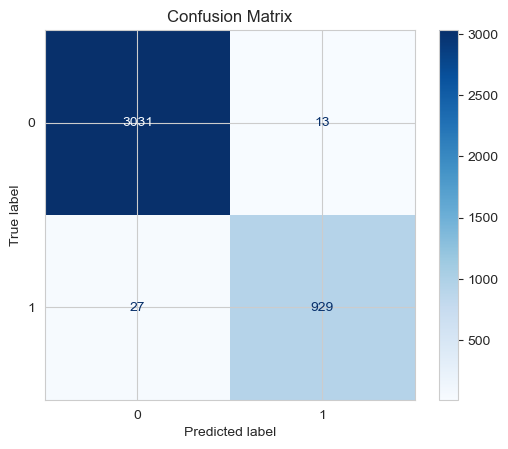

In [40]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

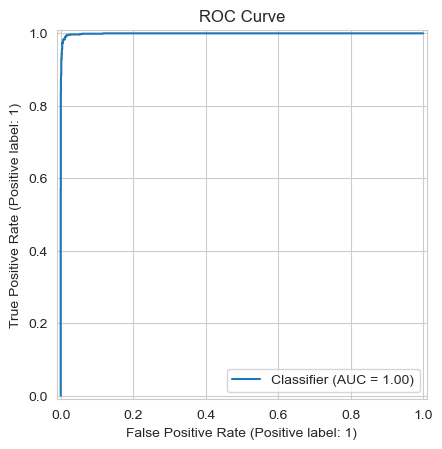

In [41]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve")
plt.show()

In [42]:
tn, fp, fn, tp = cm.ravel()

cost_false_positive = fp * 50000
cost_false_negative = fn * 8000

total_cost = (
    cost_false_positive +
    cost_false_negative
)

print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

print(f"Cost of False Positives: ${cost_false_positive:,.2f}")
print(f"Cost of False Negatives: ${cost_false_negative:,.2f}")
print(f"Total Business Cost: ${total_cost:,.2f}")

False Positives: 13
False Negatives: 27
Cost of False Positives: $650,000.00
Cost of False Negatives: $216,000.00
Total Business Cost: $866,000.00


In [43]:
results = X_test.copy()

results["Actual"] = y_test.values
results["Prediction"] = y_pred

results["Correct"] = (
    results["Actual"] ==
    results["Prediction"]
)

In [44]:
if "AnnualIncome" in results.columns:

    results["IncomeGroup"] = pd.qcut(
        results["AnnualIncome"],
        q=4,
        labels=[
            "Low",
            "Medium",
            "High",
            "Very High"
        ]
    )

    segment_performance = (
        results.groupby("IncomeGroup")
        ["Correct"]
        .mean()
        .reset_index()
    )

    segment_performance

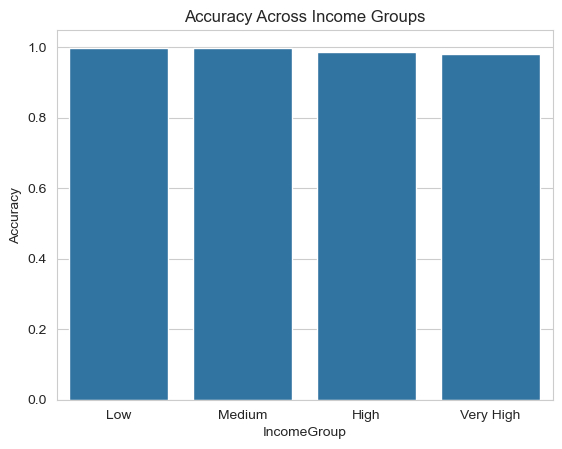

In [45]:
if "AnnualIncome" in results.columns:

    sns.barplot(
        data=segment_performance,
        x="IncomeGroup",
        y="Correct"
    )

    plt.title(
        "Accuracy Across Income Groups"
    )

    plt.ylabel("Accuracy")
    plt.show()

In [46]:
feature_names = (
    best_model.named_steps["preprocessor"]
    .get_feature_names_out()
)
importances = (
    best_model.named_steps["model"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = (
    importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
)

importance_df.head(15)

,Feature,Importance
27,num__RiskScore,0.480263
26,num__TotalDebtToIncomeRatio,0.119493
19,num__MonthlyIncome,0.097079
1,num__AnnualIncome,0.096599
24,num__InterestRate,0.034536
4,num__LoanAmount,0.022258
23,num__BaseInterestRate,0.016196
22,num__NetWorth,0.015712
25,num__MonthlyLoanPayment,0.014331
17,num__TotalAssets,0.013582


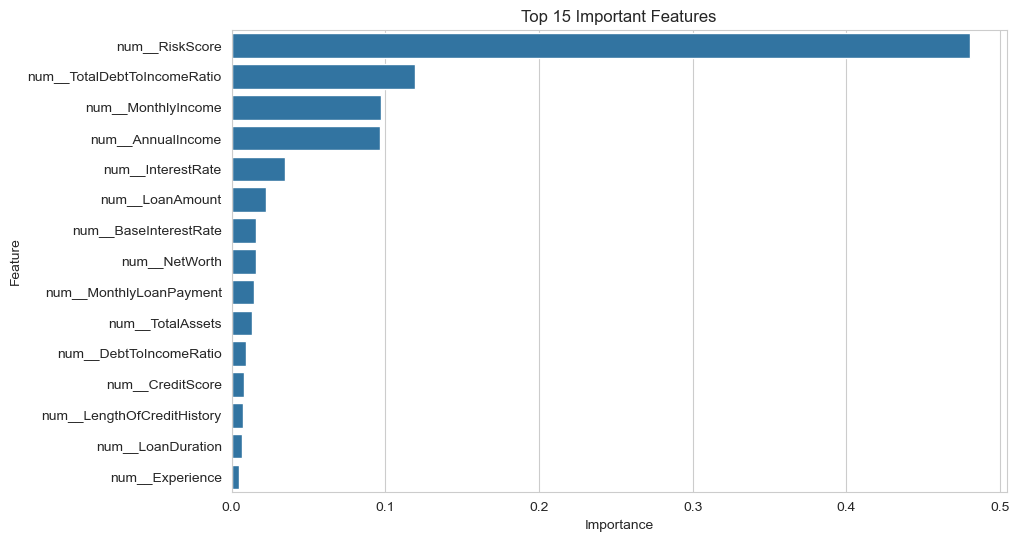

In [47]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.show()